<a href="https://colab.research.google.com/github/Sarasii22/Google-Colab-Examples/blob/main/Custering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#load the dataset as a pandas dataframe
#mount google drive in a colab environment
#load on;y the following features
#longitude, latidude , mediun house value

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Verify the file path is correct. You can use the file browser in the left sidebar to find the correct path.
house_data = pd.read_csv("/content/drive/MyDrive/ML/housing.csv", usecols ={'Longitude','Latitude','MedHouseVal'})
house_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Latitude,Longitude,MedHouseVal
0,37.88,-122.23,4.526
1,37.86,-122.22,3.585
2,37.85,-122.24,3.521
3,37.85,-122.25,3.413
4,37.85,-122.25,3.422


<Axes: xlabel='Longitude', ylabel='Latitude'>

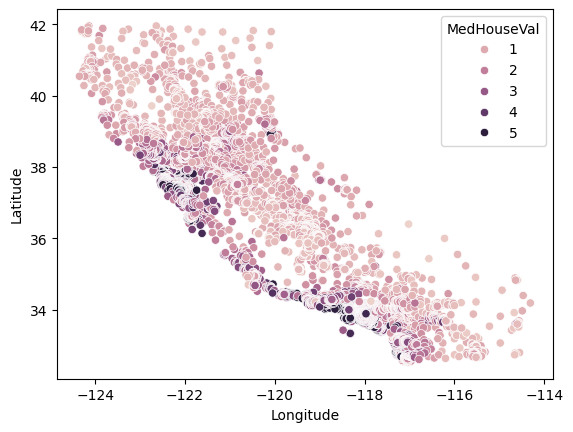

In [ ]:
#use seaborn to visualize data
import seaborn as sns
sns.scatterplot(data = house_data, x='Longitude', y='Latitude', hue='MedHouseVal')

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    house_data[['Longitude', 'Latitude']],
    house_data[['MedHouseVal']],
    test_size=0.33,
    random_state=0
)


In [ ]:
#scale

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
#model implementation
#use k = 3

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=11, n_init='auto')
#n_init = 'auto' + determines how many times k-means runs with different
#initial centroids
kmeans.fit(x_train_scaled)

KMeans(n_clusters=3, random_state=11)

<Axes: xlabel='Longitude', ylabel='Latitude'>

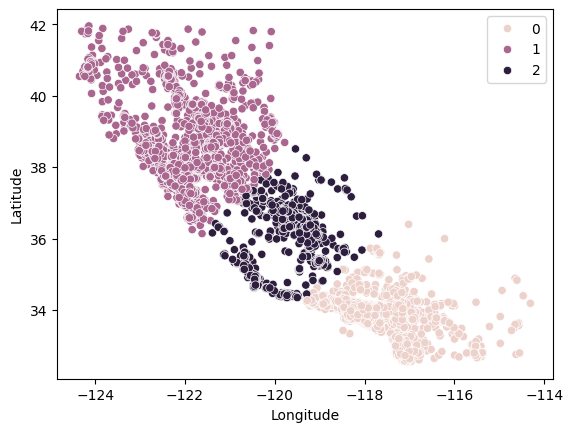

In [ ]:
#display clustering using seaborn
sns.scatterplot(data=x_train, x='Longitude', y='Latitude', hue=kmeans.labels_)

<Axes: ylabel='MedHouseVal'>

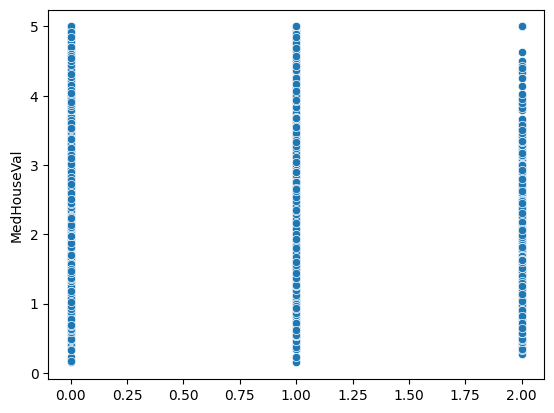

In [ ]:
#use seabor
sns.scatterplot(x = kmeans.labels_, y = y_train['MedHouseVal'])

In [ ]:
#the silhouette_score function calculates a score for each sample, which measures
#overall silhouette score returened by this function is the average of the silhouette
from sklearn.metrics import silhouette_score
silhouette_score(x_train_scaled, kmeans.labels_, metric='euclidean')

np.float64(0.6461157864450173)

In [ ]:
#use elbow method to  select the best number of clusters for the problem

K = range(1, 15)
fits = [] #sore the trained KMeans modes for each value of k
score = [] #store the inertia value for each trained KMeans model

for k in K:
  #train the model for current value of k on training data
  model = KMeans(n_clusters=k, random_state=11, n_init='auto').fit(x_train_scaled)

  #append the model to fits
  fits.append(model)

  #append the silhouette score to scores
  score.append(model.inertia_) #inertia_ attribute of the trained model contains

<Axes: >

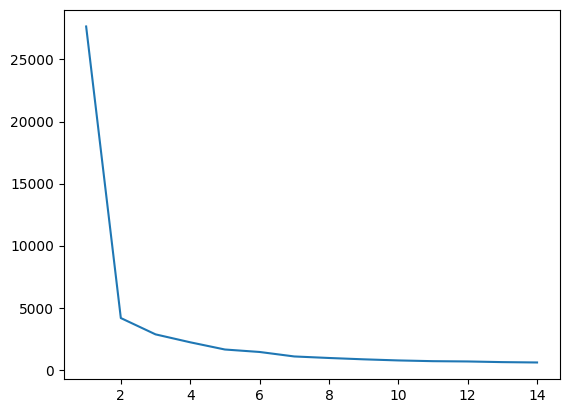

In [ ]:
#display the outcome of  the elbow method
sns.lineplot(x=K, y=score)

In [ ]:
#use the selected k to train a new model
#model implementation
kmeans = KMeans(n_clusters=2, random_state=11, n_init='auto')
kmeans.fit(x_train_scaled)

KMeans(n_clusters=2, random_state=11)

<Axes: xlabel='Longitude', ylabel='Latitude'>

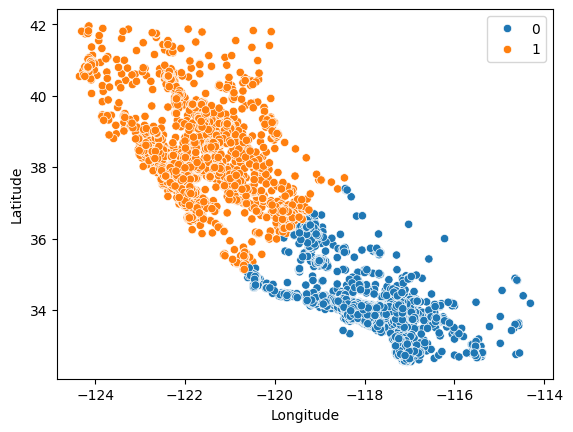

In [ ]:
#calculate the sihouette score
sns.scatterplot(data=x_train, x='Longitude', y='Latitude', hue=kmeans.labels_)